# Google Speech Commands

Load Google Speech Commands v0.02 via HuggingFace, confirm 105,829 clips at 16 kHz,
verify the 10-command + unknown + silence class split. Report class distribution (some commands may have
slightly more examples). Listen to 10 samples per class to verify audio quality.

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torchaudio
import torchcodec
from torchaudio.datasets import SPEECHCOMMANDS
from IPython.display import Audio, display

from datasets import load_dataset

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

DATA_ROOT = "./data"
os.makedirs(DATA_ROOT, exist_ok=True)

In [ ]:
train_set = SPEECHCOMMANDS(DATA_ROOT, download=True, subset="training")
val_set = SPEECHCOMMANDS(DATA_ROOT, download=True, subset="validation")
test_set = SPEECHCOMMANDS(DATA_ROOT, download=True, subset="testing")

print(f"Train: {len(train_set)} \nVal: {len(val_set)} \nTest: {len(test_set)}")
print(f"Total: {len(train_set) + len(val_set)+len(test_set)}")

100%|██████████| 2.26G/2.26G [00:28<00:00, 85.3MB/s]


Train: 84843 
Val: 9981 
Test: 11005
Total: 105829


##### Inspecting first example tuple structure

In [ ]:
waveform, sample_rate, label, speaker_id, utterance_number = train_set[0]

print(f"Waveform shape: {waveform.shape}")
print(f"Sample rate: {sample_rate} Hz")
print(f"Label: '{label}'")
print(f"Speaker ID: '{speaker_id}'")
print(f"Utterance Number: {utterance_number}")
print(f"Duration: {waveform.shape[1] / sample_rate:.3f}s")


Waveform shape: torch.Size([1, 16000])
Sample rate: 16000 Hz
Label: 'backward'
Speaker ID: '0165e0e8'
Utterance Number: 0
Duration: 1.000s


All samples verified at 16000 Hz

In [42]:
sr_df = pd.DataFrame(
    [train_set[i][1] for i in range(len(train_set))],
    columns=["sample_rate"]
)

assert sr_df["sample_rate"].nunique() == 1, "Not all sample rates are equal!"
print(f"All samples verified at {sr_df['sample_rate'].iloc[0]} Hz")

All samples verified at 16000 Hz


##### Looks like we have far more labels than we initially stated:
['backward', 'bed', 'bird', 'cat', 'dog', 'down', 'eight', 'five', 'follow', 'forward', 'four', 'go', 'happy', 'house', 'learn', 'left', 'marvin', 'nine', 'no', 'off', 'on', 'one', 'right', 'seven', 'sheila', 'six', 'stop', 'three', 'tree', 'two', 'up', 'visual', 'wow', 'yes', 'zero']

In [ ]:
labels_df = pd.DataFrame([train_set[i][2] for i in range(len(train_set))], columns=["label"])

unique_labels = set(labels_df["label"])

print(sorted(unique_labels))

['backward', 'bed', 'bird', 'cat', 'dog', 'down', 'eight', 'five', 'follow', 'forward', 'four', 'go', 'happy', 'house', 'learn', 'left', 'marvin', 'nine', 'no', 'off', 'on', 'one', 'right', 'seven', 'sheila', 'six', 'stop', 'three', 'tree', 'two', 'up', 'visual', 'wow', 'yes', 'zero']


In [40]:
value_counts = pd.DataFrame(labels_df.value_counts()).reset_index()
value_counts

,label,count
0,zero,3250
1,five,3240
2,yes,3228
3,seven,3205
4,nine,3170
5,one,3140
6,down,3134
7,no,3130
8,two,3111
9,stop,3111


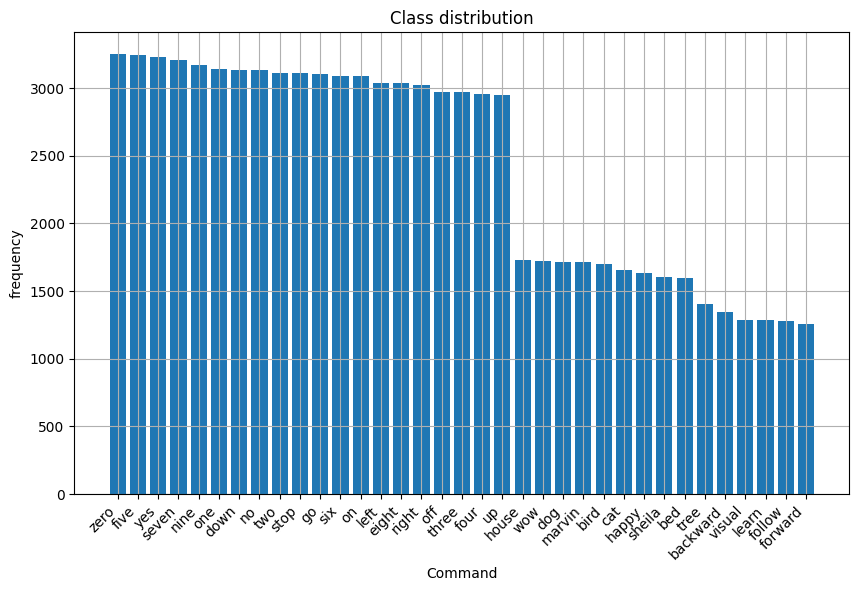

In [ ]:
fig, ax = plt.subplots(figsize = (10,6))
ax.bar(value_counts['label'], value_counts['count'])
ax.set_xlabel("Command")
ax.set_ylabel('frequency')
plt.xticks(rotation=45, ha='right')
ax.set_title("Class distribution")
ax.grid()
plt.show()

In [ ]:
indices = random.sample(range(len(train_set)), 5)

for i in indices:
    waveform, sample_rate, label, speaker_id, utterance_number = train_set[i]
    print(f"Label: {label} | Speaker: {speaker_id} | Utterance: {utterance_number}")
    display(Audio(waveform.numpy(), rate=sample_rate))

Label: zero | Speaker: b0f5b16d | Utterance: 2


Label: five | Speaker: 226537ab | Utterance: 2


Label: bird | Speaker: 353b4d33 | Utterance: 1


Label: nine | Speaker: 2fcb6397 | Utterance: 1


Label: left | Speaker: 779de043 | Utterance: 1


# MUSAN Dataset

Load the MUSAN data via Hugging Face. Verfiy the noise samples are at 16kHz, aligns with the Google Speech Commands dataset's sample rate.

In [ ]:
# Load MUSAN dataset
ds = load_dataset("FluidInference/musan")

Repo card metadata block was not found. Setting CardData to empty.


In [ ]:
print(f"Splits available: {list(ds.keys())}")
print(f"Train: {len(ds['train'])}")
print(f"\nFeatures: {ds['train'].features}")

Splits available: ['train']
Train: 774

Features: {'audio': Audio(sampling_rate=None, decode=True, stream_index=None), 'label': ClassLabel(names=['free-sound', 'sound-bible'])}


In [ ]:
# Inspect a single sample
sample = ds["train"][0]

print(f"Keys: {list(sample.keys())}")

# Accessing the label value and its corresponding name
label_value = sample['label']
label_name = ds["train"].features["label"].names[label_value]

print(f"Label Value: {label_value}")
print(f"Label Name: '{label_name}'")
print(f"Sample rate: {sample['audio']['sampling_rate']} Hz")

waveform = torch.tensor(sample["audio"]["array"]).unsqueeze(0).float()
sample_rate = sample["audio"]["sampling_rate"]

print(f"Waveform shape: {waveform.shape}")
print(f"Duration: {waveform.shape[1] / sample_rate:.3f}s")

Keys: ['audio', 'label']
Label Value: 0
Label Name: 'free-sound'
Sample rate: 16000 Hz
Waveform shape: torch.Size([1, 282540])
Duration: 17.659s


In [44]:
# Sample rate distribution
sr_df = pd.DataFrame(
    [ds["train"][i]["audio"]["sampling_rate"] for i in range(min(200, len(ds["train"])))],
    columns=["sample_rate"]
)

assert sr_df["sample_rate"].nunique() == 1, "Not all MUSAN sample rates are equal!"
print(f"All MUSAN samples verified at {sr_df['sample_rate'].iloc[0]} Hz")

All MUSAN samples verified at 16000 Hz


In [55]:
# Category distribution
category_df = pd.DataFrame(
    [ds["train"].features["label"].names[ds["train"][i]["label"]] for i in range(len(ds["train"]))],
    columns=["category"]
)

unique_categories = sorted(set(category_df["category"]))
print(f"Unique categories: {unique_categories}")

value_counts = category_df["category"].value_counts().reset_index()
value_counts.columns = ["category", "count"]

print(value_counts)

Unique categories: ['free-sound', 'sound-bible']
      category  count
0   free-sound    728
1  sound-bible     46


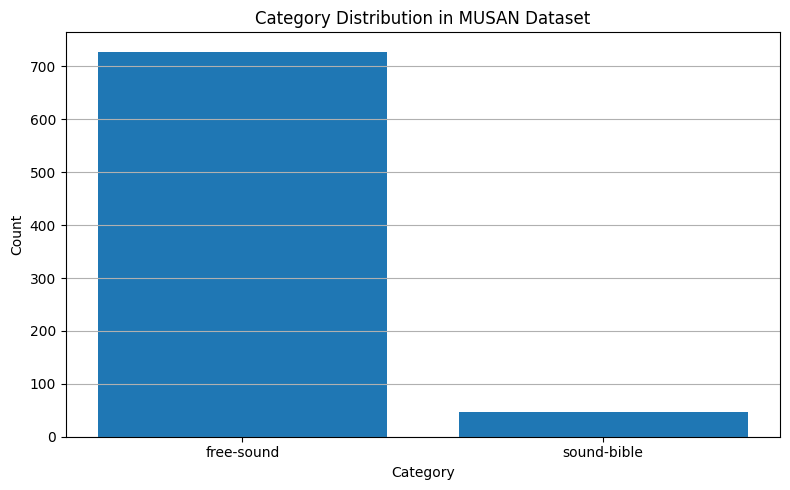

In [52]:
# Category distribution bar chart
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(value_counts["category"], value_counts["count"])
ax.set_xlabel("Category")
ax.set_ylabel("Count")
ax.set_title("Category Distribution in MUSAN Dataset")
ax.grid(axis='y')
plt.tight_layout()
plt.show()

In [57]:
# Listen to random samples per category
for cat in unique_categories:
    cat_indices = [i for i in range(len(ds["train"]))
                   if ds["train"].features["label"].names[ds["train"][i]["label"]] == cat]
    sampled = random.sample(cat_indices, min(4, len(cat_indices)))

    print(f"\n{cat.upper()} samples")
    for i in sampled:
        item = ds["train"][i]
        waveform = np.array(item["audio"]["array"])
        sr = item["audio"]["sampling_rate"]
        label = ds["train"].features["label"].names[item["label"]]
        print(f"Category: {label} | Duration: {len(waveform)/sr:.2f}s | Sample rate: {sr} Hz")
        display(Audio(waveform, rate=sr))

Output hidden; open in https://colab.research.google.com to view.